# EDA (analyse exploratoire) — le jeu de données ERBB2

**Note d'honnêteté** : ce notebook aurait dû exister *avant* `02_rdkit_descriptors_qsar.ipynb`, pas après. Il a été ajouté suite à une question directe ("as-tu fait une EDA, y a-t-il un déséquilibre de classe, des outliers ?") posée après coup — la réponse honnête était "pas de façon systématique". Ce notebook comble ce manque : déséquilibre de classe, validité des SMILES, outliers, distributions par classe, corrélations entre descripteurs. Les résultats obtenus n'invalident pas les modèles déjà entraînés, mais expliquent en partie *pourquoi* ils marchent aussi bien (à mettre en regard de `06_scaffold_validation_applicability_domain.ipynb`, qui pose la même question sous un angle différent).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

df = pd.read_csv("../data/raw/erbb2_activities.csv")

def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        "molecular_weight": Descriptors.MolWt(mol), "logp": Descriptors.MolLogP(mol),
        "h_bond_donors": Lipinski.NumHDonors(mol), "h_bond_acceptors": Lipinski.NumHAcceptors(mol),
        "rotatable_bonds": Descriptors.NumRotatableBonds(mol), "tpsa": Descriptors.TPSA(mol),
        "aromatic_rings": Descriptors.NumAromaticRings(mol), "ring_count": Descriptors.RingCount(mol),
        "heavy_atoms": Descriptors.HeavyAtomCount(mol), "molar_refractivity": Descriptors.MolMR(mol),
    }

desc_df = pd.DataFrame(df["canonical_smiles"].apply(compute_descriptors).tolist())
data = pd.concat([df.reset_index(drop=True), desc_df], axis=1)
DESCRIPTOR_COLS = list(desc_df.columns)
data.shape

(1070, 17)

## 1. Déséquilibre de classe

In [2]:
print(data["active"].value_counts())
print(data["active"].value_counts(normalize=True).round(3))

active
1    546
0    524
Name: count, dtype: int64
active
1    0.51
0    0.49
Name: proportion, dtype: float64


**51% actif / 49% inactif — pas de déséquilibre de classe.** Bonne nouvelle : contrairement à beaucoup de jeux de données biologiques (souvent très déséquilibrés, ex. 95%/5%), celui-ci est sain. Pas besoin de rééchantillonnage (SMOTE, class weights...).

## 2. Validité des SMILES

In [3]:
n_invalid = desc_df.isnull().all(axis=1).sum()
print(f"SMILES invalides (non parsables par RDKit) : {n_invalid} / {len(df)}")

SMILES invalides (non parsables par RDKit) : 0 / 1070


**0 SMILES invalide** — cohérent avec le fait qu'ils viennent directement de l'API PubChem (déjà validés côté serveur), pas d'une saisie manuelle.

## 3. Distributions et outliers (méthode IQR)

/var/folders/75/d1n71q151vv3qsg_b_qw77840000gn/T/ipykernel_29551/1956878349.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(desc_df[col].dropna(), vert=True)
/var/folders/75/d1n71q151vv3qsg_b_qw77840000gn/T/ipykernel_29551/1956878349.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(desc_df[col].dropna(), vert=True)
/var/folders/75/d1n71q151vv3qsg_b_qw77840000gn/T/ipykernel_29551/1956878349.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(desc_df[col].dropna(), vert=True)
/var/folders/75/d1n71q151vv3qsg_b_qw77840000gn/T/ipykernel_29551/1956878349.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in M

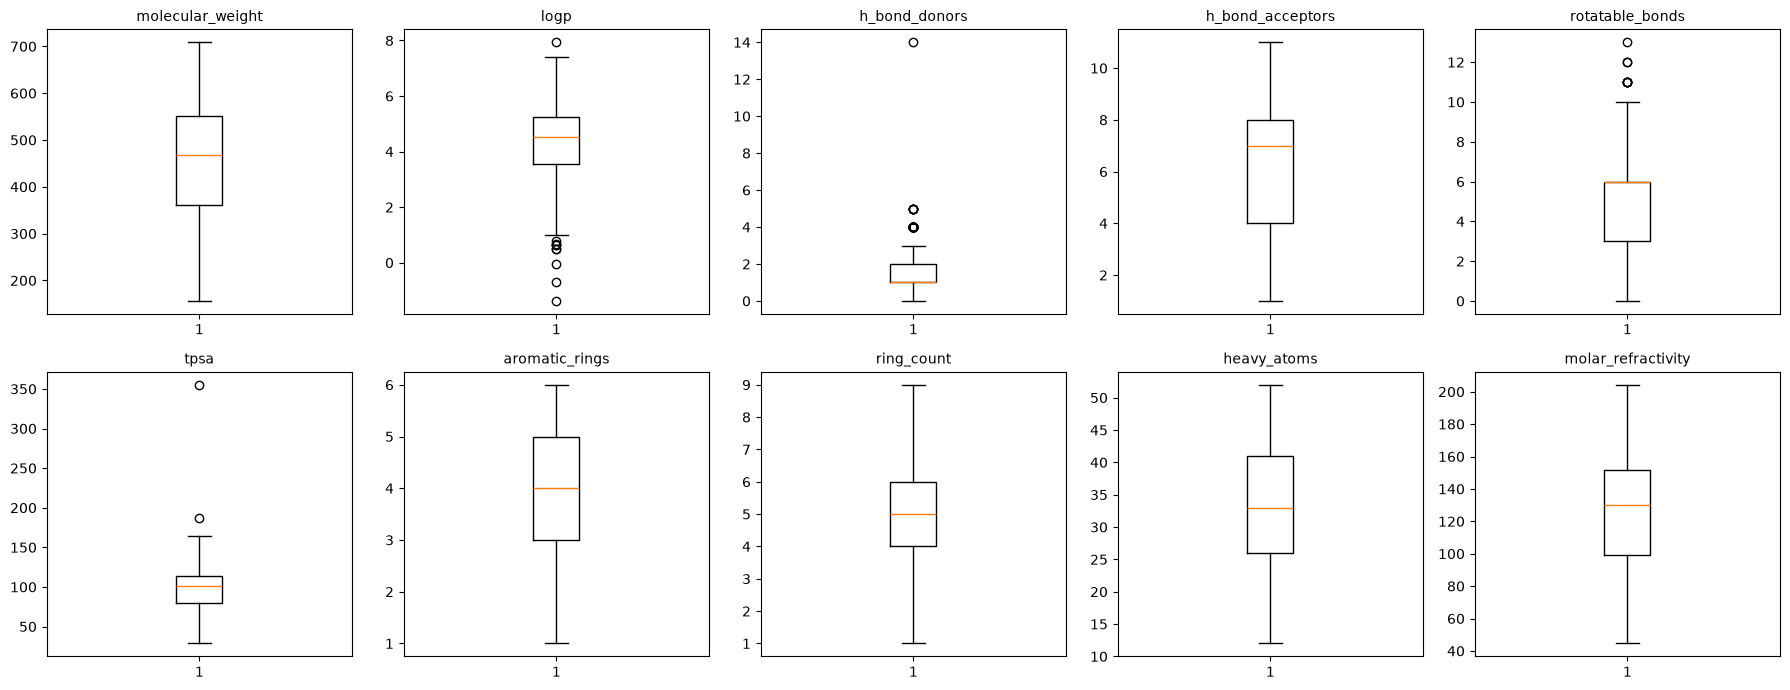

Descripteur            Bornes IQR (1.5x)         Outliers  
molecular_weight       [   76.8,   836.5]          0 (0.0%)
logp                   [    1.0,     7.8]         10 (0.9%)
h_bond_donors          [   -0.5,     3.5]         56 (5.2%)
h_bond_acceptors       [   -2.0,    14.0]          0 (0.0%)
rotatable_bonds        [   -1.5,    10.5]          8 (0.7%)
tpsa                   [   27.9,   165.1]          2 (0.2%)
aromatic_rings         [    0.0,     8.0]          0 (0.0%)
ring_count             [    1.0,     9.0]          0 (0.0%)
heavy_atoms            [    3.5,    63.5]          0 (0.0%)
molar_refractivity     [   21.0,   229.8]          0 (0.0%)


In [4]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.flat, DESCRIPTOR_COLS):
    ax.boxplot(desc_df[col].dropna(), vert=True)
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.show()

print(f"{'Descripteur':22s} {'Bornes IQR (1.5x)':25s} {'Outliers':10s}")
for col in DESCRIPTOR_COLS:
    q1, q3 = desc_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((desc_df[col] < low) | (desc_df[col] > high)).sum()
    print(f"{col:22s} [{low:7.1f}, {high:7.1f}]        {n_out:3d} ({100*n_out/len(desc_df):.1f}%)")

**Lecture** : la plupart des colonnes n'ont pas ou peu d'outliers au sens IQR. `h_bond_donors` en a le plus (5,2%) — mais c'est un artefact de la méthode IQR sur une distribution discrète et naturellement asymétrique (la plupart des molécules ont 0-2 donneurs, quelques-unes en ont plus — c'est de la vraie chimie, pas une erreur de données), pas un vrai problème.

## 4. Le cas du vrai outlier structurel

In [5]:
outlier = data[data["tpsa"] > 250]
outlier[["cid", "canonical_smiles", "h_bond_donors", "h_bond_acceptors", "tpsa", "molecular_weight", "active"]]

,cid,canonical_smiles,h_bond_donors,h_bond_acceptors,tpsa,molecular_weight,active
608,136027061,CC(=NNC(=N)N)C1=CC(=CC(=C1)NC(=O)C2=CC(=CC=C2)...,14,10,355.24,708.796,0


Une seule molécule (CID 136027061) sort nettement du lot : 14 donneurs H, TPSA 355 (le reste du jeu de données plafonne à ~165), poids 709 g/mol — une structure de type triamidine/macrocycle, chimiquement atypique pour ce jeu de données. Point rassurant : elle est étiquetée **inactive**, elle ne pousse donc pas artificiellement les performances sur la classe active. On la laisse dans le jeu de données (elle est réelle, pas une erreur de saisie), mais elle explique à elle seule les valeurs maximales de `tpsa` et `h_bond_donors` vues dans le describe().

## 5. Corrélations entre descripteurs (multicolinéarité)

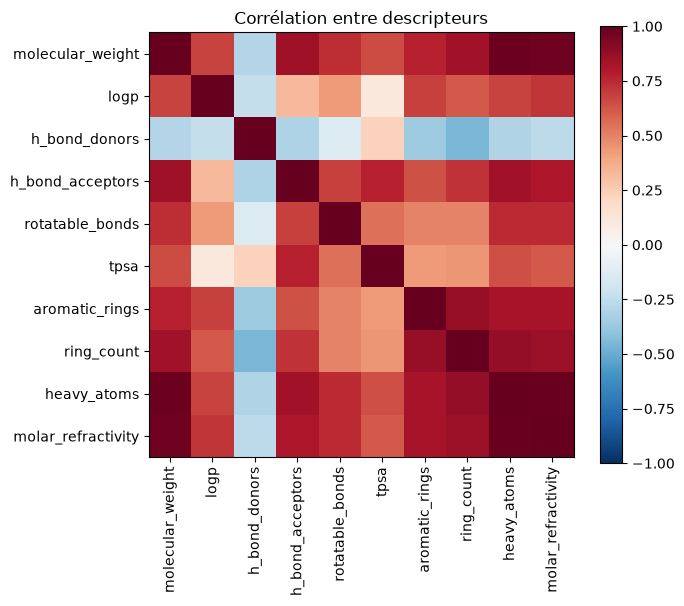

Paires fortement corrélées (|r| > 0.75) :
  molecular_weight     <-> h_bond_acceptors     : 0.85
  molecular_weight     <-> aromatic_rings       : 0.78
  molecular_weight     <-> ring_count           : 0.84
  molecular_weight     <-> heavy_atoms          : 0.98
  molecular_weight     <-> molar_refractivity   : 0.97
  h_bond_acceptors     <-> tpsa                 : 0.78
  h_bond_acceptors     <-> heavy_atoms          : 0.84
  h_bond_acceptors     <-> molar_refractivity   : 0.81
  aromatic_rings       <-> ring_count           : 0.87
  aromatic_rings       <-> heavy_atoms          : 0.82
  aromatic_rings       <-> molar_refractivity   : 0.82
  ring_count           <-> heavy_atoms          : 0.88
  ring_count           <-> molar_refractivity   : 0.86
  heavy_atoms          <-> molar_refractivity   : 0.99


In [6]:
corr = desc_df.corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr)), corr.columns, rotation=90)
ax.set_yticks(range(len(corr)), corr.columns)
plt.colorbar(im)
plt.title("Corrélation entre descripteurs")
plt.tight_layout()
plt.show()

print("Paires fortement corrélées (|r| > 0.75) :")
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.75:
            print(f"  {corr.columns[i]:20s} <-> {corr.columns[j]:20s} : {corr.iloc[i, j]:.2f}")

**Forte multicolinéarité** entre `molecular_weight`, `heavy_atoms` et `molar_refractivity` (r > 0,97 entre elles) — attendu physiquement (une plus grosse molécule a plus d'atomes et un poids plus élevé, quasi tautologique). XGBoost gère bien la colinéarité (contrairement à une régression linéaire), donc ce n'est pas un problème de modélisation, mais ça veut dire qu'on a en réalité moins de 10 signaux réellement indépendants — plutôt 3-4 "familles" (taille globale, polarité/TPSA, flexibilité, aromaticité).

## 6. Le vrai résultat important : actifs vs inactifs sont systématiquement différents en *taille*

In [7]:
means_by_class = data.groupby("active")[DESCRIPTOR_COLS].mean().round(2).T
means_by_class.columns = ["Inactif", "Actif"]
means_by_class["Écart"] = (means_by_class["Actif"] - means_by_class["Inactif"]).round(2)
means_by_class

,Inactif,Actif,Écart
molecular_weight,370.50,533.53,163.03
logp,3.73,4.91,1.18
h_bond_donors,2.19,1.19,-1.00
h_bond_acceptors,4.66,7.88,3.22
rotatable_bonds,4.01,6.15,2.14
tpsa,85.80,105.73,19.93
aromatic_rings,3.36,4.75,1.39
ring_count,3.75,6.14,2.39
heavy_atoms,26.43,39.02,12.59
molar_refractivity,102.47,146.48,44.01


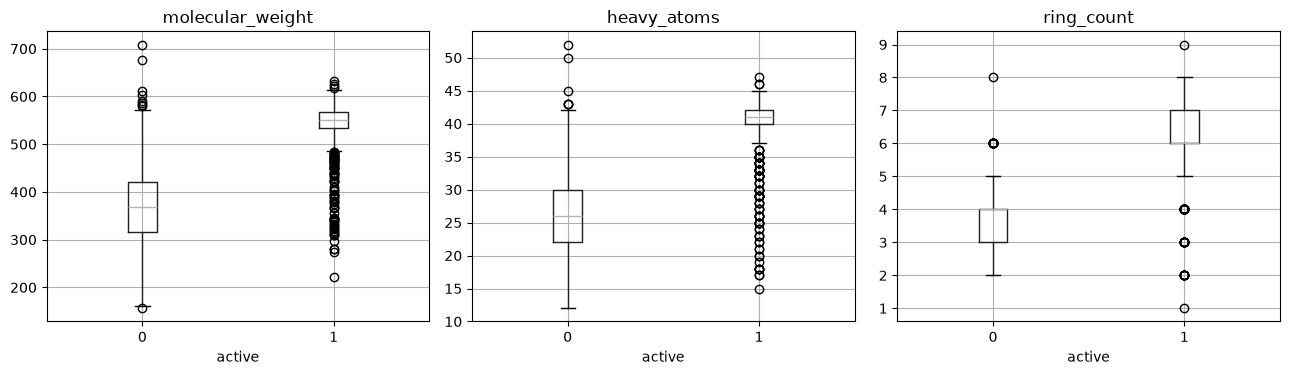

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ["molecular_weight", "heavy_atoms", "ring_count"]):
    data.boxplot(column=col, by="active", ax=ax)
    ax.set_title(col)
plt.suptitle("")
plt.tight_layout()
plt.show()

**Constat** : les molécules actives sont en moyenne **44% plus lourdes** que les inactives (533,5 vs 370,5 g/mol), avec plus d'atomes lourds (39 vs 26), plus de cycles (6,1 vs 3,75) et un LogP plus élevé (4,91 vs 3,73). C'est un écart massif, pas un simple bruit statistique.

**Pourquoi c'est important à savoir** : ça veut dire qu'une partie non négligeable de la capacité du modèle à séparer actif/inactif vient probablement de la **taille/complexité globale** de la molécule, pas uniquement d'une reconnaissance fine de la structure qui se lie à HER2 — un peu comme le résultat déjà trouvé sur le bit d'empreinte dominant (motif aminopyrimidine/quinazoline, section 6 du guide). Deux explications possibles, non exclusives :
1. **Une raison biologique plausible** : les molécules actives ici sont surtout des inhibiteurs de kinase optimisés (issus de campagnes de chimie médicinale), naturellement plus complexes que les molécules "génériques" du pool inactif.
2. **Un artefact de composition du jeu de données** : PubChem agrège des essais de sources et de types différents (criblage primaire vs essais de confirmation sur des candidats déjà optimisés) — les actifs et les inactifs ne viennent pas forcément d'un design expérimental parfaitement apparié.

**Conséquence pratique** : à interpréter avec la même prudence que le résultat de la section 6 du guide (`docs/GUIDE_COMPLET.md`) — le modèle est probablement plus un bon détecteur de "molécule de type inhibiteur de kinase, complexe et de bonne taille" qu'un détecteur fin et sélectif de "se lie spécifiquement à HER2". Ça n'invalide pas le modèle (le test de permutation de la section 6 confirme qu'il n'y a pas de fuite), mais ça calibre correctement ce qu'on peut en attendre.

## 7. Pour la diversité structurale (squelettes chimiques)

Déjà traitée en détail dans `06_scaffold_validation_applicability_domain.ipynb` : 1070 molécules pour seulement 499 squelettes de Bemis-Murcko uniques (un squelette a 66 molécules qui en dérivent) — un vrai déséquilibre structurel, qui a motivé la validation par squelette plutôt qu'aléatoire. Pas répété ici pour éviter la redondance, voir ce notebook pour le détail complet.